# GPU programming is cost-model first

A 1-hour course for database & systems researchers. One thesis, proven by measurement on the hardware in front of us:

> **You don't pick an algorithm and then make the chip run it. You compute the cost model first -- bytes moved, passes over memory, arithmetic intensity, where the data lives, how you access it -- and *that* selects the algorithm before you write a line.** Asymptotic optimality is not hardware-neutral; "best" is a function of the chip.

**The chip:** a single **RTX 6000 Ada** (sm_89, AD102) -- 48 GB **GDDR6** ~960 GB/s, **96 MB L2**, register file ~36 MB. A bandwidth machine with a large automatic cache, bolted to a massively parallel engine. Everything below is measured on it.

**The spine:** two sorts tell the whole story from two angles --
- **radix** = *massive parallelism collapses the algorithm; linear-time wins*,
- **merge** = *the cache / access-pattern / memory-hierarchy story* --
and a production library is just a **frozen cost-model decision tree** that picks between them for you.

## Time budget -- 1 hour (~55 min content + 5 Q&A)

| # | section | min | note |
|---|---|---|---|
| 0 | Thesis + hardware | 3 | core |
| 1 | Bandwidth identity | 4 | core |
| 2 | Cache cliff (measure at GB) | 4 | core |
| 3 | **Cost model in two lines** (thrust dispatch) | 5 | the hook |
| 4 | Two sorts (framing) | 2 | core |
| 4a | Radix: passes-law + 4x merge | 9 | core |
| 4b | Merge: hierarchy + ablation | 9 | core |
| 5 | Kernel is ~10% (rug pull) | 6 | keep |
| 6 | Model is a fiction (SASS) | 4 | **cuttable** |
| 7 | Histogram (supporting) | 6 | **cuttable** |
| 8 | Closing | 3 | core |
| - | Q&A | 5 | buffer |

The two **cuttable** rows (SASS + histogram ~10 min) are the slack: spend it on
more centerpiece depth (e.g. more ablation knobs) or trim to land under the hour.

In [1]:
%matplotlib inline
import subprocess, re, os
import matplotlib.pyplot as plt

ROOT = os.getcwd()
GPU, CPU, RADIX, MERGE, INK, CEIL = "#76b900", "#5b6770", "#0b84a5", "#c0392b", "#23272b", "#b9bfc4"
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#eef1f3", "axes.axisbelow": True})

def sh(cmd, cwd=None, timeout=900):
    r = subprocess.run(cmd, shell=True, cwd=cwd or ROOT, capture_output=True, text=True, timeout=timeout)
    return r.stdout + r.stderr

def grab(text, pat):
    m = re.search(pat, text); return float(m.group(1)) if m else float("nan")

# build everything the notebook runs
sh("make -s -C demo1_bandwidth; make -s -C demo2_sort; make -s -C demo3_rugpull; make -s -C demo5_histogram")
sh("cd demo6_mergesort && nvcc -O3 -std=c++17 -arch=sm_89 -o cub_compare cub_compare.cu && "
   "nvcc -O3 -std=c++17 -arch=sm_89 -o thrust_compare thrust_compare.cu")
print("built.")

built.


## 1. The chip's identity is bandwidth  (~4 min)

A trivial streaming copy. The CPU's STREAM Triad tops out well below its (small) DRAM peak; the GPU's copy kernel saturates its (much larger) bus. The story is the *ratio*, and that the GPU number comes from a kernel you could write in your sleep.

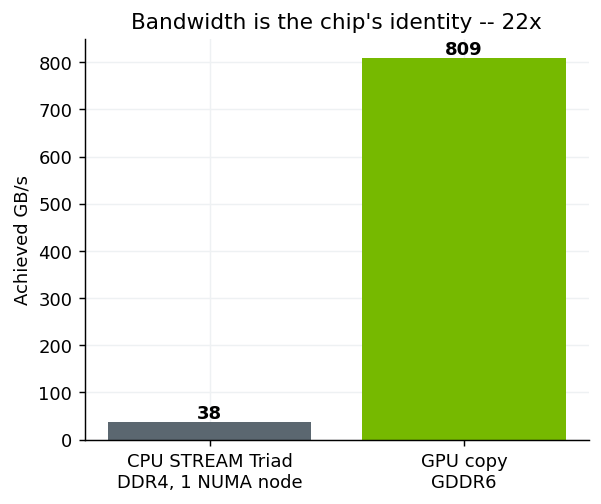

In [2]:
g = grab(sh("./stream_gpu", cwd=f"{ROOT}/demo1_bandwidth"), r"copy kernel:\s*([\d.]+)")
numa = "numactl --cpunodebind=0 --membind=0 " if sh("which numactl").strip() else ""
c = grab(sh(f"OMP_NUM_THREADS=6 OMP_PROC_BIND=close OMP_PLACES=cores {numa}./stream_cpu",
            cwd=f"{ROOT}/demo1_bandwidth"), r"triad bandwidth:\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["CPU STREAM Triad\nDDR4, 1 NUMA node", "GPU copy\nGDDR6"], [c, g], color=[CPU, GPU])
ax.set_ylabel("Achieved GB/s"); ax.set_title(f"Bandwidth is the chip's identity -- {g/c:.0f}x")
for i, v in enumerate([c, g]): ax.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontweight="bold")
plt.show()

## 2. ...but the cache hides it -- so measure at GB scale  (~4 min)

Run the *same naive sort kernel* across sizes. Below 96 MB the array lives in L2 and throughput is ~4x higher than reality; cross the L2 and you fall off a cliff to true HBM-bound speed.

Two lessons in one plot: (a) the memory hierarchy is the chip; (b) **any benchmark that fits in cache is lying to you** -- everything past here runs at >= 1 GB.

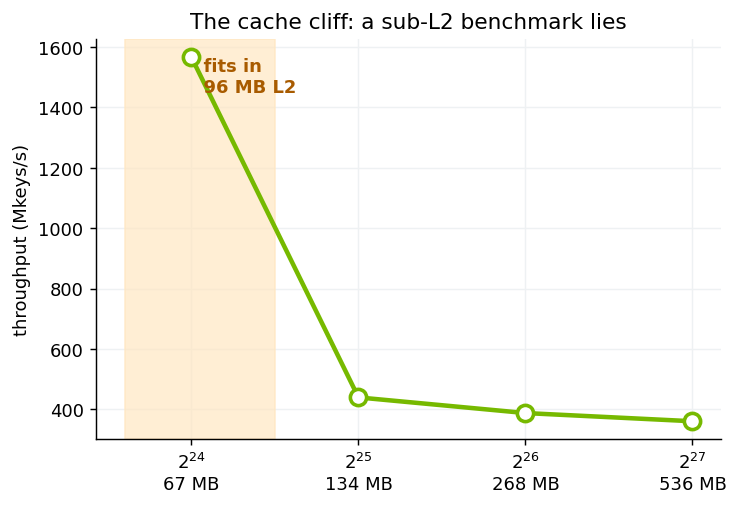

In [3]:
sizes = [24, 25, 26, 27]
mk = [grab(sh(f"./v0_naive {s} 5", cwd=f"{ROOT}/demo2_sort"), r"([\d.]+)\s*Mkeys/s") for s in sizes]
fig, ax = plt.subplots(figsize=(6.2, 4))
x = range(len(sizes))
ax.plot(x, mk, "o-", color=GPU, lw=2.5, ms=9, mfc="white", mew=2)
ax.axvspan(-0.4, 0.5, color="#ffe7c2", alpha=0.7)
ax.text(0, mk[0], "  fits in\n  96 MB L2", va="top", color="#a85b00", fontweight="bold")
ax.set_xticks(list(x)); ax.set_xticklabels([f"$2^{{{s}}}$\n{2**s*4//10**6} MB" for s in sizes])
ax.set_ylabel("throughput (Mkeys/s)"); ax.set_title("The cache cliff: a sub-L2 benchmark lies")
plt.show()

## 3. The cost model, in two lines of user code  (~5 min, the hook)

The highest-level GPU sort API -- `thrust::sort`, the `std::sort` equivalent -- *already* embodies the thesis. Its dispatch (`thrust/system/cuda/detail/sort.h`, `can_use_primitive_sort`) picks at **compile time**:

```cpp
// arithmetic key (int/float...) AND default less/greater  -> RADIX  (cub::DeviceRadixSort)
// custom comparator, or non-arithmetic key                -> MERGE  (cub::DeviceMergeSort)
```

So these two calls sort the *same data into the same order* -- the only difference is a comparator whose type happens to mean `a < b` -- yet one is several times slower, because its type blocks the radix path. **The cost model, triggered by a type, invisible to the user.**

n=2^28 (268M keys)
  thrust::sort(x)           -> radix :   19.333 ms  [PASS]
  thrust::sort(x, MyLess()) -> merge :   54.562 ms  [PASS]
  one custom comparator cost you 2.8x -- the cost model, by type.



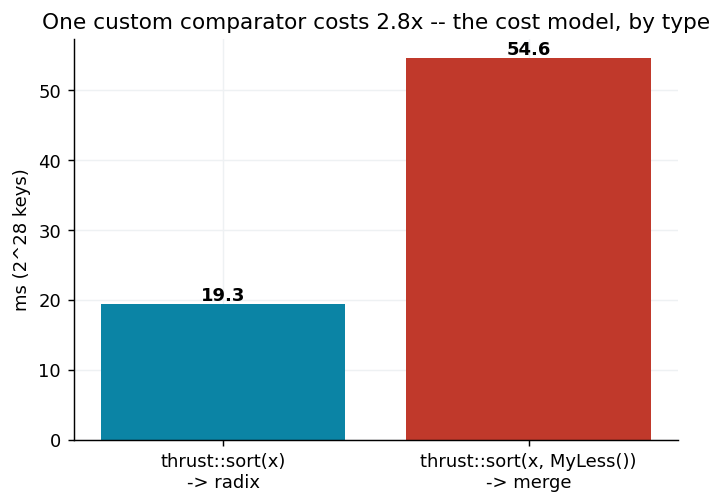

In [4]:
out = sh("./thrust_compare 28 6", cwd=f"{ROOT}/demo6_mergesort"); print(out)
r = grab(out, r"-> radix :\s*([\d.]+)"); m = grab(out, r"-> merge :\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["thrust::sort(x)\n-> radix", "thrust::sort(x, MyLess())\n-> merge"], [r, m], color=[RADIX, MERGE])
ax.set_ylabel("ms (2^28 keys)"); ax.set_title(f"One custom comparator costs {m/r:.1f}x -- the cost model, by type")
for i, v in enumerate([r, m]): ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontweight="bold")
plt.show()

## 4. Two sorts, two truths about the chip  (framing ~2 min)

Why ship *both*? Because there's no single best sort -- the cost model picks the game. The two algorithms illuminate the two halves of "what is a GPU."

### 4a. Radix -- *massive parallelism collapses the algorithm; linear time wins*  (~9 min)

On a CPU you're taught O(n log n) comparison sort is optimal and you ignore radix for its constants. The GPU inverts the cost model: with near-perfect data-parallelism the per-element work is free, so **only passes over memory count** -- and O(n)-pass radix beats O(n log n) merge. First, the naive-to-radix arc (bitonic is just the bad global-memory baseline that motivates it); then radix vs a *fully optimized* CUB merge at GB scale.

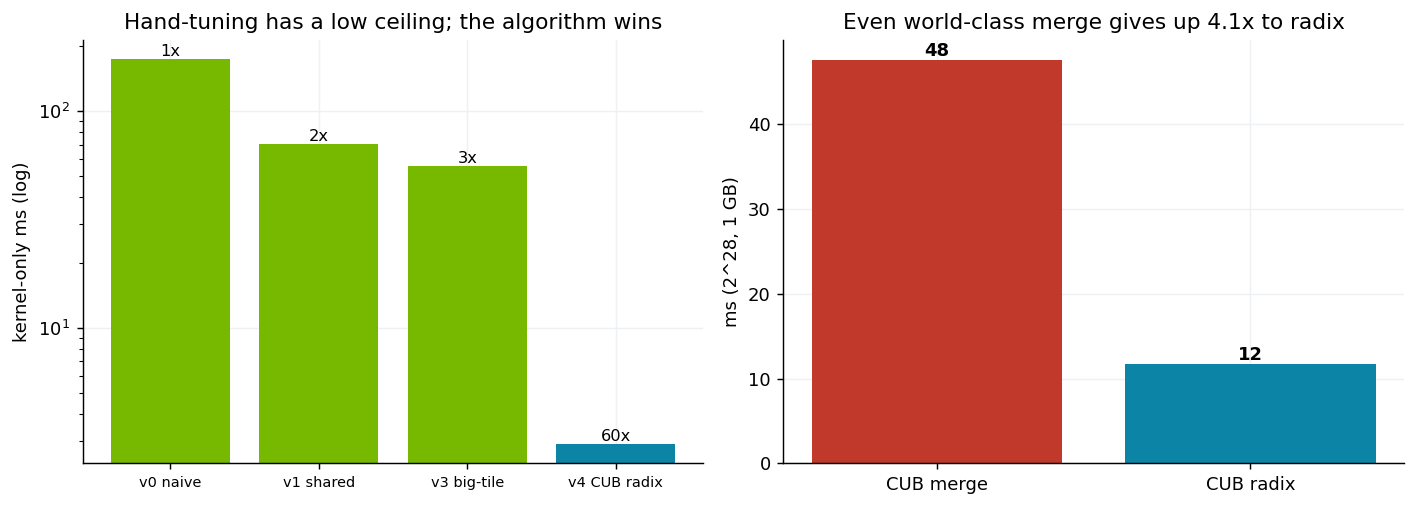

In [5]:
# the arc: naive global bitonic -> shared -> bigger tile -> CUB radix (2^26)
ARC = [("v0_naive","v0 naive"),("v1_shared","v1 shared"),("v3_multiblock","v3 big-tile"),("v4_cub","v4 CUB radix")]
ms = {lbl: grab(sh(f"./{b} 26 10", cwd=f"{ROOT}/demo2_sort"), r"([\d.]+)\s*ms") for b, lbl in ARC}
base = ms["v0 naive"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
bars = a1.bar(list(ms), list(ms.values()), color=[GPU, GPU, GPU, RADIX]); a1.set_yscale("log")
a1.set_ylabel("kernel-only ms (log)"); a1.set_title("Hand-tuning has a low ceiling; the algorithm wins")
for b, v in zip(bars, ms.values()): a1.text(b.get_x()+b.get_width()/2, v, f"{base/v:.0f}x", ha="center", va="bottom", fontsize=9)
a1.tick_params(axis="x", labelsize=8)
# radix vs fully-optimized CUB merge at GB scale
out = sh("./cub_compare 28 6", cwd=f"{ROOT}/demo6_mergesort")
cm = grab(out, r"merge sort :\s*([\d.]+)"); cr = grab(out, r"radix sort :\s*([\d.]+)")
a2.bar(["CUB merge", "CUB radix"], [cm, cr], color=[MERGE, RADIX]); a2.set_ylabel("ms (2^28, 1 GB)")
a2.set_title(f"Even world-class merge gives up {cm/cr:.1f}x to radix")
for i, v in enumerate([cm, cr]): a2.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout(); plt.show()

### 4b. Merge -- *the cache / access-pattern / memory-hierarchy story*  (~9 min)

Merge is the **general** sort (any comparator, where radix can't go), and its CUB implementation is pure hierarchy choreography -- you don't change the algorithm, you change *where the data lives and how you touch it*:
- **per-thread register sorting-networks** (`StableOddEvenSort` on `keys[ITEMS_PER_THREAD]`),
- **shared-memory merge tiles** with **`MergePath` co-rank** to make the merge parallel and coalesced,
- **device-level merge** of tiles, again partitioned by MergePath.

The honest open question (the live deep-dive): on this hardware, does *gradually tuning* those layers climb, or has the big L2 + fast shared atomics flattened the middle of the arc? That's an **ablation** -- start from CUB's final code, remove one optimization at a time -- still to be run. (What we *do* know: the fully-tuned result is the `CUB merge` bar above, and radix still beats it 4x.)

## 5. The kernel is ~10%  (~6 min)

Take the best hand-rolled sort and wrap it the way a query stage actually runs: allocate, copy in, sort, copy out, free -- every iteration. The kernel never changes, yet per-iteration time swings wildly. `cudaMalloc`/`cudaFree` are synchronous driver calls; a stream-ordered pool (`cudaMallocAsync`) and a CUDA graph claw the time back -- none of it by touching the kernel.

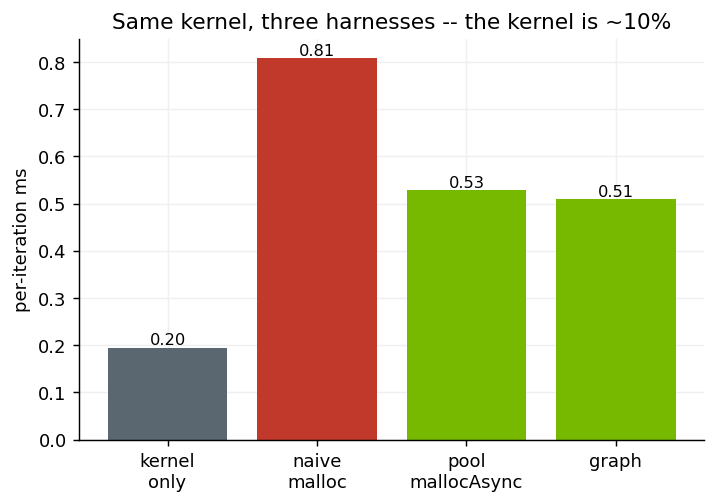

In [6]:
H = ["naive", "pool", "graph"]
outs = {h: sh(f"./{h}_harness 20 200", cwd=f"{ROOT}/demo3_rugpull") for h in H}
pit = {h: grab(outs[h], r"per-iter\s*:\s*([\d.]+)") for h in H}
kon = grab(outs["naive"], r"kernel-only\s*:\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.bar(["kernel\nonly", "naive\nmalloc", "pool\nmallocAsync", "graph"], [kon, pit["naive"], pit["pool"], pit["graph"]],
       color=[CPU, MERGE, GPU, GPU])
ax.set_ylabel("per-iteration ms"); ax.set_title("Same kernel, three harnesses -- the kernel is ~10%")
for i, v in enumerate([kon, pit["naive"], pit["pool"], pit["graph"]]): ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
plt.show()

## 6. The model is a fiction  (~4 min, cuttable)

One GPU here, so no live hardware swap. The compile-time version is sharper: the *same source* compiles to different machine code per architecture, because `ptxas` exploits arch-specific instructions. You write `min/max`; on Hopper it becomes `VIMNMX`. CUB goes further and ships per-arch kernels emitting Hopper *collective* instructions the CUDA C model never surfaces. (Loaded from `demo4_hwswap/run_all.sh`.)

In [7]:
so = f"{ROOT}/demo4_hwswap/sass_out"
if os.path.isdir(so) and os.path.exists(f"{so}/v3_multiblock_ops90.txt"):
    for v in ["v3_multiblock", "v4_cub"]:
        a = set(open(f"{so}/{v}_ops89.txt").read().split()); b = set(open(f"{so}/{v}_ops90.txt").read().split())
        print(f"{v}: sm_90-only opcodes -> {', '.join(sorted(b - a))}")
else:
    print("Run:  cd demo4_hwswap && ./run_all.sh   (then re-run this cell)")

v3_multiblock: sm_90-only opcodes -> LDC, LDC.64, MOV, P2R, S2UR, ULEA, UMOV, VIADD, VIMNMX
v4_cub: sm_90-only opcodes -> CS2R, ENDCOLLECTIVE, HFMA2.MMA, LDC, LDC.64, REDG.E.ADD.STRONG.GPU, UISETP.GT.AND, VIADD, VIMNMX, WARPSYNC.ALL, WARPSYNC.COLLECTIVE, WARPSYNC.EXCLUSIVE


## 7. Supporting demo: histogram = the contention story (and "high-card -> just sort")  (~6 min, cuttable)

A histogram reads N keys once, trivial compute -> arithmetic intensity ~0.5 ops/byte, deeply memory-bound, floor = bytes/bandwidth (~1.1 ms for 1 GB). The lesson is *whether you reach that floor*:
- **naive global atomics**: ~2% of peak -- not bandwidth-bound, **atomic-contention-bound** (the bus sits idle while warps stall on serialized atomics).
- **shared-memory privatization**: ~92% -- at the roofline.

The controlled experiment (`v1b`, privatize in *global* memory) showed ~19x of that win is **contention reduction**, only ~2.5x is shared memory -- *measure, don't assume which fix mattered*. And at high cardinality privatization can't fit, atomics plateau, and the right answer becomes... **sort + run-length-encode**. Histogram = sort + a pass; the primitive underneath is sort.

v0_global          n=2^28 zipf=0.0    59.597 ms     18.0 GB/s ( 1.9% peak)  floor=1.12ms  [PASS]
v1_shared          n=2^28 zipf=0.0     1.219 ms    881.2 GB/s (91.8% peak)  floor=1.12ms  [PASS]


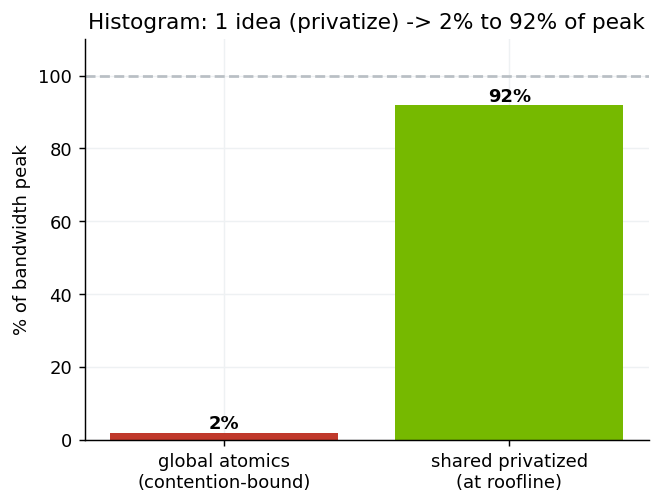

In [8]:
v0 = sh("./v0_global_atomic 28 5 0", cwd=f"{ROOT}/demo5_histogram")
v1 = sh("./v1_shared_privatized 28 5 0", cwd=f"{ROOT}/demo5_histogram")
p0 = grab(v0, r"\(\s*([\d.]+)% peak\)"); p1 = grab(v1, r"\(\s*([\d.]+)% peak\)")
print(v0.strip()); print(v1.strip())
fig, ax = plt.subplots(figsize=(5.6, 4))
ax.bar(["global atomics\n(contention-bound)", "shared privatized\n(at roofline)"], [p0, p1], color=[MERGE, GPU])
ax.axhline(100, ls="--", color=CEIL); ax.set_ylabel("% of bandwidth peak"); ax.set_ylim(0, 110)
ax.set_title("Histogram: 1 idea (privatize) -> 2% to 92% of peak")
for i, v in enumerate([p0, p1]): ax.text(i, v, f"{v:.0f}%", ha="center", va="bottom", fontweight="bold")
plt.show()

## Closing: the library is a frozen cost-model decision tree  (~3 min)

Everything pointed one way. `thrust::sort` picks radix-vs-merge by *type*, at compile time. CUB ships *both* sorts and *both* a `BLOCK_HISTO_ATOMIC` and a `BLOCK_HISTO_SORT`. The experts didn't find *the* answer -- they encoded the **question** and a chooser, because the right choice is a function of the input and the chip.

So the one sentence the audience should leave with: **compute the cost model first.** Bytes moved, passes, arithmetic intensity, where the data lives, how you access it -- that arithmetic selects the algorithm, tells you when to stop tuning, and tells you which library call to make. On a GPU, that is the program; the kernel is a detail.